# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [3]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [4]:
dataset

<module 'keras.datasets.fashion_mnist' from 'c:\\Users\\Varushet\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\keras\\datasets\\fashion_mnist\\__init__.py'>

In [5]:
len(dataset.load_data()[0])

2

In [6]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [8]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [9]:
print("Hay",len(X_train))

Hay 60000


In [10]:
print("Hay",len(X_test))

Hay 10000


In [11]:
X_test.shape

(10000, 28, 28)

In [12]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

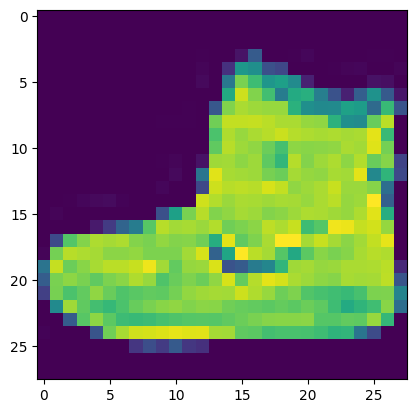

In [13]:
from matplotlib.pylab import imshow


imshow(X_train[0]);

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [14]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

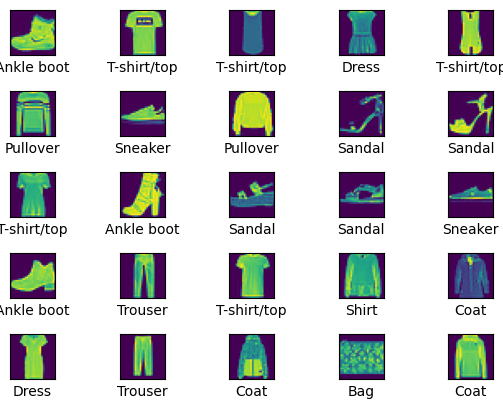

In [15]:
for x in range(25):
    plt.subplot(5,5, x+1)
    plt.yticks([])
    plt.xticks([])
    plt.imshow(X_train[x])
    plt.xlabel(class_names[y_train[x]])
    plt.subplots_adjust(wspace=0.9, hspace=0.8)

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [16]:
capas = [
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(units = 300, activation='relu'),
    keras.layers.Dense(units = 100, activation='relu'),
    keras.layers.Dense(units = 10, activation='softmax')
]
model = keras.models.Sequential(capas)

c:\Users\Varushet\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [17]:
model.compile(
    optimizer = keras.optimizers.SGD(),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy()]
)

In [18]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [19]:
X_val = X_train[-10000:]
y_val = y_train[-10000:]

X_train = X_train[:-10000]
y_train = y_train[:-10000]

In [20]:
history = model.fit(
    X_train,
    y_train,
    batch_size = 128,
    epochs = 10,
    validation_data = (X_val, y_val)
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0780 - sparse_categorical_accuracy: 0.6649 - val_loss: 0.7410 - val_sparse_categorical_accuracy: 0.7558
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6647 - sparse_categorical_accuracy: 0.7873 - val_loss: 0.6044 - val_sparse_categorical_accuracy: 0.8015
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5726 - sparse_categorical_accuracy: 0.8135 - val_loss: 0.5569 - val_sparse_categorical_accuracy: 0.8060
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5258 - sparse_categorical_accuracy: 0.8244 - val_loss: 0.5137 - val_sparse_categorical_accuracy: 0.8230
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4975 - sparse_categorical_accuracy: 0.8320 - val_loss: 0.4940 - val_sparse_categorical_accuracy: 0.8278
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4781 - sparse_categorical_accuracy: 0.8369 - val_loss: 0.4977 - val_sparse_categorical_accuracy: 0.8235
Epoc

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [21]:
results = model.evaluate(X_test, y_test)
results

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4685 - sparse_categorical_accuracy: 0.8330


[0.4685080051422119, 0.8330000042915344]

## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [22]:
y_pred = model.predict(X_test)
print(y_pred.shape)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step
(10000, 10)


array([[1.3992008e-05, 1.5649037e-05, 2.2411230e-05, ..., 2.0388564e-01,
        3.1533462e-03, 6.2204170e-01],
       [2.1133000e-04, 1.4964891e-06, 8.2371104e-01, ..., 7.6236829e-11,
        5.3233973e-05, 1.4934265e-08],
       [1.4564890e-05, 9.9991167e-01, 4.2187667e-06, ..., 8.0844586e-07,
        1.8545695e-07, 1.0568075e-09],
       ...,
       [5.7145629e-02, 2.9015289e-05, 1.6742569e-03, ..., 1.8455602e-04,
        8.3852118e-01, 9.9982310e-05],
       [3.3460565e-05, 9.9757344e-01, 2.8845529e-05, ..., 3.0128143e-05,
        3.4662282e-06, 2.9192802e-06],
       [3.7776394e-04, 9.8915002e-04, 7.9063466e-04, ..., 2.9385981e-01,
        1.9951666e-02, 2.2801314e-02]], shape=(10000, 10), dtype=float32)

El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [23]:
y_pred[0]

array([1.3992008e-05, 1.5649037e-05, 2.2411230e-05, 8.4100966e-06,
       7.2980579e-06, 1.7074169e-01, 1.0989163e-04, 2.0388564e-01,
       3.1533462e-03, 6.2204170e-01], dtype=float32)

In [24]:
y_pred[0].argmax()

np.int64(9)

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [25]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

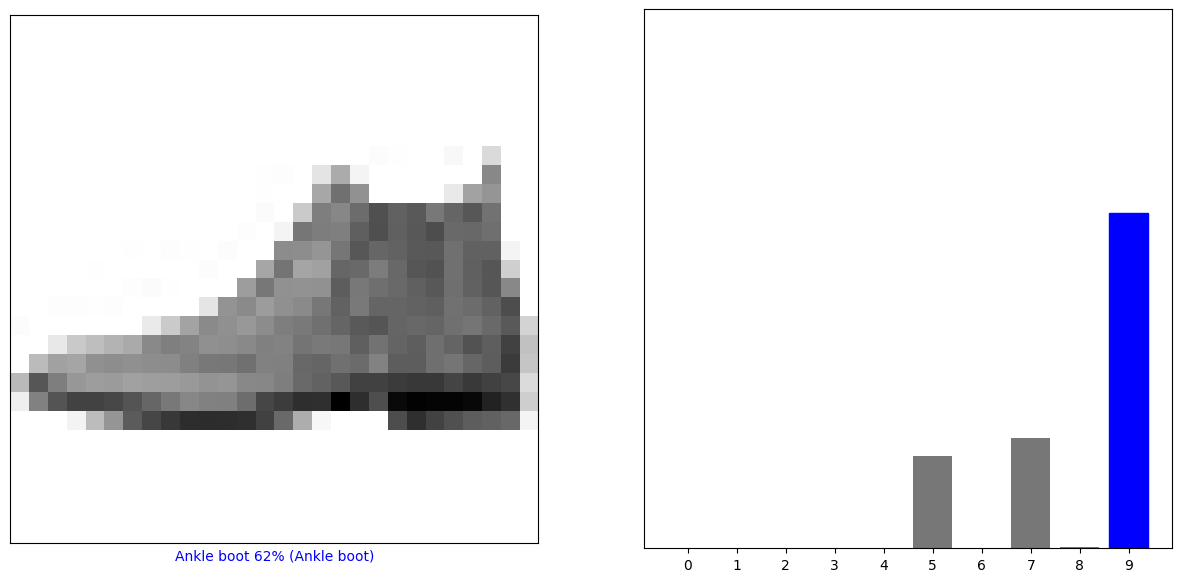

In [26]:
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, y_pred[i], y_test)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

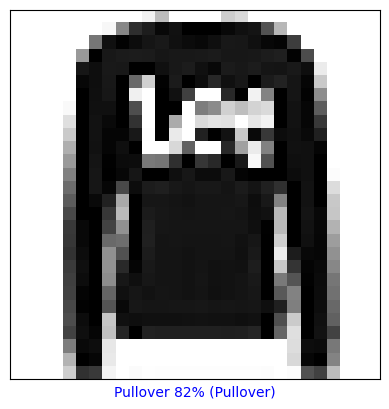

In [27]:
plot_image(1, y_pred[1], y_test, X_test)

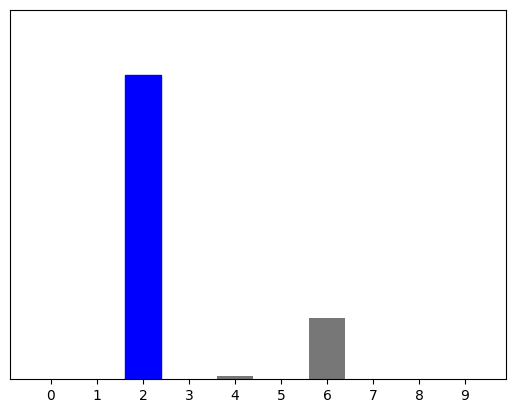

In [28]:
plot_value_array(1, y_pred[1], y_test,)

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

Evalúa tu modelo con una matriz de confusión e interprétala.

In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test).argmax(axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step


array([[759,   5,  14,  50,   4,   1, 153,   0,  14,   0],
       [  3, 952,   7,  28,   5,   0,   3,   0,   2,   0],
       [ 10,   3, 654,  10, 140,   1, 170,   0,  12,   0],
       [ 25,  17,  10, 850,  30,   1,  61,   0,   6,   0],
       [  0,   1,  73,  34, 732,   1, 151,   0,   8,   0],
       [  0,   1,   0,   0,   0, 928,   0,  48,   1,  22],
       [119,   2,  83,  33,  67,   3, 665,   0,  28,   0],
       [  0,   0,   0,   0,   0,  44,   0, 907,   0,  49],
       [  0,   1,   7,   8,   2,   4,  23,   6, 949,   0],
       [  0,   0,   0,   0,   0,  20,   1,  44,   1, 934]])

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [34]:
img_batch = np.expand_dims(X_test[5], axis=0)

prediction = model.predict(img_batch)

prediction.argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


np.int64(1)